In [1]:
import numpy as np
from sklearn.cluster import KMeans

c:\Python312\Lib\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.sparse import issparse


In [2]:
from sklearn.datasets import make_blobs
np.random.seed(42)
X, y = make_blobs(n_samples=600, centers=7, n_features=2, random_state=42)

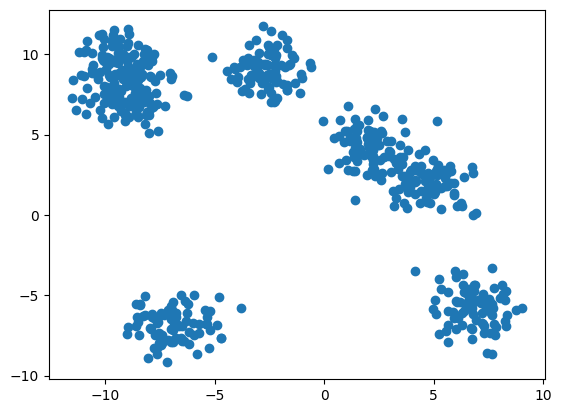

In [15]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])

In [3]:
#tree structure

class HKMnode:
    def __init__(self, centroids=None, children=None, leaf=True, points=None, indices=None):
        self.centroids = centroids
        self.children = children or []
        self.points = points
        self.leaf = leaf
        self.indices = indices

In [4]:
#indexing

def hierarchicalIndexing(data, indices, branching_factor, level, max_level, min_points):
    if data.shape[0] < min_points or level == max_level:
        leaf = HKMnode(points = data, indices=indices, leaf=True)
        return leaf
    
    kmeans = KMeans(n_clusters=branching_factor, random_state=42).fit(data)

    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    node = HKMnode(centroids=centroids, leaf=False)

    for i in range(branching_factor):
        points_in_cluster = data[labels == i]
        idx_in_cluster = indices[labels == i]
        child = hierarchicalIndexing(
            points_in_cluster,
            idx_in_cluster,
            branching_factor,
            level + 1,
            max_level,
            min_points
        )
        node.children.append(child)
    
    return node


    

In [ ]:
# Searching
# class HKMnode:
#     def __init__(self, centroids=None, children=None, leaf=True, points=None):
#         self.centroids = centroids
#         self.children = children or []
#         self.points = points
#         self.leaf = leaf
def find_nearest_neighbor(node, point, return_index = False):

    norm_sq_point = point @ point
    if(node.leaf == True):
        # go through the points, find the closest one
        distances = []
        for i in range(node.points.shape[0]):
            neighbor = node.points[i]
            neighbor_sq = neighbor @ neighbor
            dist = norm_sq_point + neighbor_sq - 2 * (point @ neighbor)
            distances.append(dist)
        
        idx = distances.index(min(distances))
        if(return_index):
            return (node.points[idx], node.indices[idx])
        return node.points[idx]
            
    
    #go through the centroids and pass the closes to the find_cluster
    distance_to_centroids = []
    for i in range(node.centroids.shape[0]):
        centroid = node.centroids[i]
        centroid_sq = centroid @ centroid
        dist = norm_sq_point + centroid_sq - 2 * (point @ centroid)
        distance_to_centroids.append(dist)
    
    idx = distance_to_centroids.index(min(distance_to_centroids))
    closest_cluster = node.children[idx]

    return find_nearest_neighbor(closest_cluster, point, return_index)
    
def find_nearest_neighbor_i(node, point):

    query = np.asarray(point).reshape(-1)

    if(node.leaf == True):
        dot_prods =  node.points @ query
        idx = np.argmax(dot_prods)

        return(node.indices[idx])
    
    dot_prods = node.centroids @ query
    idx = np.argmax(dot_prods)

    return find_nearest_neighbor_i(node.children[idx], query)
    

In [8]:
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
query = np.array([-11, -3])
query = query / np.linalg.norm(query)

root2 = hierarchicalIndexing(X_norm, np.arange(X_norm.shape[0]),1, 0, 1, 1)
root = hierarchicalIndexing(X_norm, np.arange(X_norm.shape[0]), 3,0, 5, 3)

In [13]:


import time

t1 = time.perf_counter()
res = find_nearest_neighbor_i(root, query)
t1 = time.perf_counter() - t1

t2 = time.perf_counter()
res_fs = find_nearest_neighbor_i(root2, query)
t2 = time.perf_counter() - t2

print("Time to do HKM: %.4fms \nTime to do full scan: %.4fms" %(t1 * 1000, t2 * 1000))

Time to do HKM: 0.2137ms 
Time to do full scan: 0.0998ms


IndexError: invalid index to scalar variable.

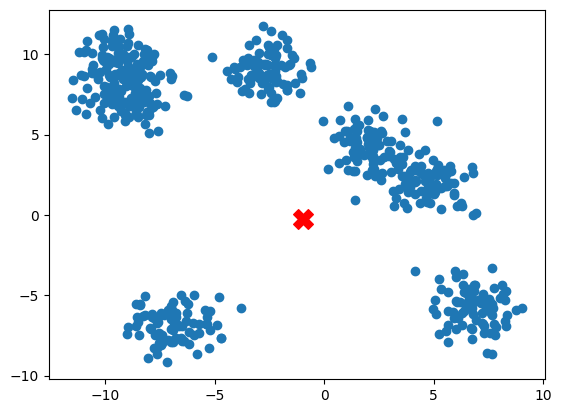

In [16]:
res_i = find_nearest_neighbor_i(root, query)
#res_i = X[res_i[1]]


plt.scatter(X[:, 0], X[:, 1])
plt.scatter(query[0], query[1], color='red', marker='X', s=200, label='Query')
plt.scatter(res_i[0], res_i[1], color='black', marker='P', s=200, label='Result')
plt.scatter(res_fs[0], res_fs[1], color='grey', marker='P', s=200, label='Result_fs')
plt.legend()
plt.show()

In [17]:
def read_fvecs(path):
    data = np.fromfile(path, dtype=np.int32)
    d = data[0]
    data = data.reshape(-1, d+1)
    # all rows, skip the first col because it stores the number of dimensions
    return data[:, 1:].view(np.float32)

def read_ivecs(path):
    data = np.fromfile(path, dtype=np.int32)
    d = data[0]
    data = data.reshape(-1, d+1)
    
    return(data[:, 1:])


In [18]:
path_to_base = "./data/sift_base.fvecs"
path_to_queries = "./data/sift_query.fvecs"
path_to_gt = "./data/sift_groundtruth.ivecs"
paths = [
    "./data/small/siftsmall_base.fvecs",
    "./data/small/siftsmall_query.fvecs",
    "./data/small/siftsmall_groundtruth.ivecs"
]

base = read_fvecs(paths[0])
queries = read_fvecs(paths[1])
ground_truths = read_ivecs(paths[2])




In [19]:
base_large = read_fvecs(path_to_base)
query_large = read_fvecs(path_to_queries)
ground_truths_large = read_ivecs(path_to_gt)



In [20]:
#normalizing the data

base_large_normalized = base_large / np.linalg.norm(base_large, axis=1, keepdims=True)
query_large_normalized = query_large / np.linalg.norm(query_large, axis=1, keepdims=True)

In [25]:



results1 = []
idx = np.random.choice(query_large_normalized.shape[0], size = 1000, replace=False)
query_samples = query_large_normalized[idx]
ground_truths_large_sample = ground_truths_large[idx]# idx
#print(idx.shape)
num_queries_large = query_samples.shape[0]

max_depths = [2, 4, 6, 10, 12] #4 
brancing_factors = [2, 4, 6, 10, 12, 14, 20] #2

for md in max_depths:
    for bf in brancing_factors:
        t = time.perf_counter()

        root4 = hierarchicalIndexing(base_large_normalized, np.arange(base_large_normalized.shape[0]),
                            bf,
                              0,
                            md,
                            100)
        t = time.perf_counter() - t
        print()
        accurate_count = 0
        accurate_count_top_5 = 0
        results = np.empty(num_queries_large, dtype=np.int32)
        cosine_similarity_hkm = []
        cosine_similarity_gt = []

        t3 = time.perf_counter()
        for q_id in range(num_queries_large):
            #print(q_id)
            q = query_samples[q_id]
            results[q_id] = find_nearest_neighbor_i(root4, q)
            # res = find_nearest_neighbor_i(root4, q)

            # true_results_idx = ground_truths_large_sample[q_id][0]
            

            # if(res == true_results_idx):
            #     accurate_count += 1
            # cos_hkm = base_large_normalized[res] @ q
            # cos_gt = base_large_normalized[true_results_idx] @ q

            # cosine_similarity_hkm.append(cos_hkm)
            # cosine_similarity_gt.append(cos_gt)

        t3 = time.perf_counter() - t3

        for q_id in range(num_queries_large):

            q = query_samples[q_id]            
            res = results[q_id]
            true_results_idx = ground_truths_large_sample[q_id]
            if(res == true_results_idx[0]):
                accurate_count += 1
            
            for i in range(5):
                if(res == true_results_idx[i]):
                    accurate_count_top_5 += 1


            cos_hkm = base_large_normalized[res] @ q
            cos_gt = base_large_normalized[true_results_idx[0]] @ q
            cosine_similarity_hkm.append(cos_hkm)
            cosine_similarity_gt.append(cos_gt)
            

        recall = accurate_count / num_queries_large
        recall5 = accurate_count_top_5 / num_queries_large
        mean_cos_hkm = np.mean(cosine_similarity_hkm)
        mean_cos_gt = np.mean(cosine_similarity_gt)
        mean_gap = mean_cos_gt - mean_cos_hkm

        print("max_depth: ", md, " branching factor: ", bf)
        print("Recall1", recall)
        print("Recall5", recall5)
        print("Time to answer queries: ", t3)
        print("Time to train: ", t)
        print("Mean GT cosine: ", mean_cos_gt)
        print("Mean HKM cosine: ", mean_cos_hkm)

        results1.append({
            "max_depth": md,
            "brancing_factor": bf,
            "recall": recall,
            "recall5": recall5,
            "train_time": t,
            "query_time": t3 / num_queries_large,
            "mean_cos_hkm": mean_cos_hkm,
            "mean_cos_gt": mean_cos_gt,
            "mean_gap": mean_gap
        })
    
    


max_depth:  2  branching factor:  2
Recall1 0.91
Recall5 0.996
Time to answer queries:  3.817658999993
Time to train:  4.467640100046992
Mean GT cosine:  0.92657644
Mean HKM cosine:  0.92562366

max_depth:  2  branching factor:  4
Recall1 0.717
Recall5 0.926
Time to answer queries:  1.405269299983047
Time to train:  7.9908560999901965
Mean GT cosine:  0.92657644
Mean HKM cosine:  0.9217747

max_depth:  2  branching factor:  6
Recall1 0.619
Recall5 0.887
Time to answer queries:  0.510453500028234
Time to train:  11.388675499998499
Mean GT cosine:  0.92657644
Mean HKM cosine:  0.9199696

max_depth:  2  branching factor:  10
Recall1 0.532
Recall5 0.835
Time to answer queries:  0.3031106000416912
Time to train:  20.434685999993235
Mean GT cosine:  0.92657644
Mean HKM cosine:  0.9186265

max_depth:  2  branching factor:  12
Recall1 0.494
Recall5 0.813
Time to answer queries:  0.2213752999668941
Time to train:  25.24463139998261
Mean GT cosine:  0.92657644
Mean HKM cosine:  0.91740453

max_

In [28]:
import pandas as pd
df1 = pd.DataFrame(results1)

In [30]:
df1.to_pickle("hkm_results.pkl")

In [32]:
df2 = pd.read_pickle("hkm_results.pkl")
df2

,max_depth,brancing_factor,recall,recall5,train_time,query_time,mean_cos_hkm,mean_cos_gt,mean_gap
0,2,2,0.910,0.996,4.467640,0.003818,0.925624,0.926576,0.000953
1,2,4,0.717,0.926,7.990856,0.001405,0.921775,0.926576,0.004802
2,2,6,0.619,0.887,11.388675,0.000510,0.919970,0.926576,0.006607
3,2,10,0.532,0.835,20.434686,0.000303,0.918626,0.926576,0.007950
4,2,12,0.494,0.813,25.244631,0.000221,0.917405,0.926576,0.009172
5,2,14,0.461,0.789,27.187906,0.000195,0.916503,0.926576,0.010074
6,2,20,0.390,0.737,35.300041,0.000141,0.914330,0.926576,0.012247
7,4,2,0.709,0.923,9.832011,0.001089,0.921676,0.926576,0.004901
8,4,4,0.400,0.740,19.828889,0.000198,0.914133,0.926576,0.012443
9,4,6,0.284,0.613,29.913007,0.000064,0.910202,0.926576,0.016374


In [22]:
results1 = []
idx = np.random.choice(query_large.shape[0], size = 1000, replace=False)
query_samples = query_large[idx]
ground_truths_large_sample = ground_truths_large[idx]# idx
#print(idx.shape)
num_queries_large = query_samples.shape[0]

max_depths = [4] #4 
brancing_factors = [2] #2

for md in max_depths:
    for bf in brancing_factors:
        t = time.perf_counter()

        root4 = hierarchicalIndexing(base_large, np.arange(base_large.shape[0]),
                            bf,
                              0,
                            md,
                            100)
        t = time.perf_counter() - t
        print()
        accurate_count = 0

        t3 = time.perf_counter()
        for q_id in range(num_queries_large):
            #print(q_id)
            q = query_samples[q_id]
            res = find_nearest_neighbor(root4, q, return_index=True)

            true_results_idx = ground_truths_large_sample[q_id][0]
            

            if(res[1] == true_results_idx):
                accurate_count += 1
        t3 = time.perf_counter() - t3
        print("max_depth: ", md, " branching factor: ", bf)
        recall = accurate_count / num_queries_large
        print("Recall1", recall)
        print("Time to answer queries: ", t3)
        print("Time to train: ", t)

        results1.append({
            "max_depth": md,
            "brancing_factor": bf,
            "recall": recall,
            "train_time": t,
            "query_time": t3 / num_queries_large
        })


max_depth:  4  branching factor:  2
Recall1 0.734
Time to answer queries:  334.2826983000268
Time to train:  10.783827400009613


In [19]:
import pandas as pd

df_1 = pd.DataFrame(results1)
print(df_1)

NameError: name 'results1' is not defined

In [69]:
df_3 = pd.DataFrame(results1)
print(df_3)

   max_depth  brancing_factor  recall  train_time  query_time
0          8                2   0.490   27.490727    0.018825
1          8                3   0.222   76.030411    0.000936
2          9                2   0.432   33.202892    0.010007
3          9                3   0.174  147.184693    0.000435


In [30]:
results_2 = []

max_depths = [2, 3, 4, 5, 6]
brancing_factors = [2, 3, 4, 5, 6, 10, 15]
num_queries = queries.shape[0]
for md in max_depths:
    for bf in brancing_factors:
        t = time.perf_counter()
        root3 = hierarchicalIndexing(base, np.arange(base.shape[0]),
                            bf,
                              0,
                            md,
                            bf)
        t = time.perf_counter() - t

        accurate_count = 0

        t3 = time.perf_counter()
        for q_id in range(num_queries):
            
            q = queries[q_id]
            res_tup = find_nearest_neighbor(root3, q, return_index=True)

            true_results_idx = ground_truths[q_id][0]
            

            if(res_tup[1] == true_results_idx):
                accurate_count += 1
        t3 = time.perf_counter() - t3
        print("max_depth: ", md, " branching factor: ", bf)
        recall = accurate_count / num_queries
        print("Recall1", recall)
        print("Time to answer queries: ", t3)
        print("Time to train: ", t)

        results_2.append({
            "max_depth": md,
            "brancing_factor": bf,
            "recall": recall,
            "train_time": t,
            "query_time": t3 / num_queries_large
        })

max_depth:  2  branching factor:  2
Recall1 0.95
Time to answer queries:  1.1662264000624418
Time to train:  0.1373689000029117
max_depth:  2  branching factor:  3
Recall1 0.83
Time to answer queries:  0.5437400999944657
Time to train:  0.1454344999510795
max_depth:  2  branching factor:  4
Recall1 0.68
Time to answer queries:  0.31097329990006983
Time to train:  0.1801731998566538
max_depth:  2  branching factor:  5
Recall1 0.74
Time to answer queries:  0.23748079990036786
Time to train:  0.2369214000646025
max_depth:  2  branching factor:  6
Recall1 0.68
Time to answer queries:  0.1844774999190122
Time to train:  0.21243120008148253
max_depth:  2  branching factor:  10
Recall1 0.55
Time to answer queries:  0.07486529997549951
Time to train:  0.35825729998759925
max_depth:  2  branching factor:  15
Recall1 0.46
Time to answer queries:  0.05170800001360476
Time to train:  0.4752927999943495
max_depth:  3  branching factor:  2
Recall1 0.86
Time to answer queries:  0.593784200027585
Time

In [33]:
import pandas as pd

df_2 = pd.DataFrame(results_2)
print(df_2)

    max_depth  brancing_factor  recall  train_time  query_time
0           2                2    0.95    0.137369    0.000117
1           2                3    0.83    0.145434    0.000054
2           2                4    0.68    0.180173    0.000031
3           2                5    0.74    0.236921    0.000024
4           2                6    0.68    0.212431    0.000018
5           2               10    0.55    0.358257    0.000007
6           2               15    0.46    0.475293    0.000005
7           3                2    0.86    0.147946    0.000059
8           3                3    0.66    0.291856    0.000021
9           3                4    0.58    0.380613    0.000011
10          3                5    0.53    0.557386    0.000008
11          3                6    0.53    0.652684    0.000005
12          3               10    0.43    1.503026    0.000003
13          3               15    0.39    3.204148    0.000003
14          4                2    0.80    0.277110    0

<Axes: xlabel='query_time', ylabel='recall'>

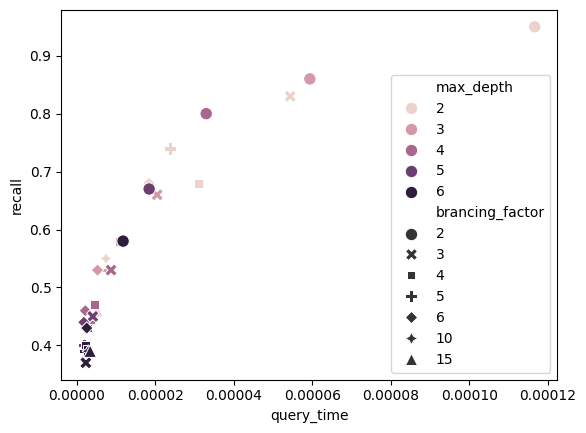

In [52]:
import seaborn as sns

sns.scatterplot(
    data=df_2,
    x="query_time",
    y="recall",
    hue="max_depth",
    style="brancing_factor",
    s=80
)


<Axes: xlabel='query_time', ylabel='recall'>

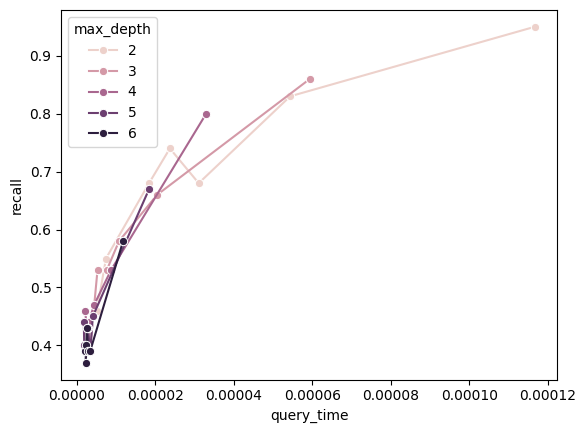

In [53]:
sns.lineplot(
    data=df_2,
    x="query_time",
    y="recall",
    hue="max_depth",
    marker="o"
)


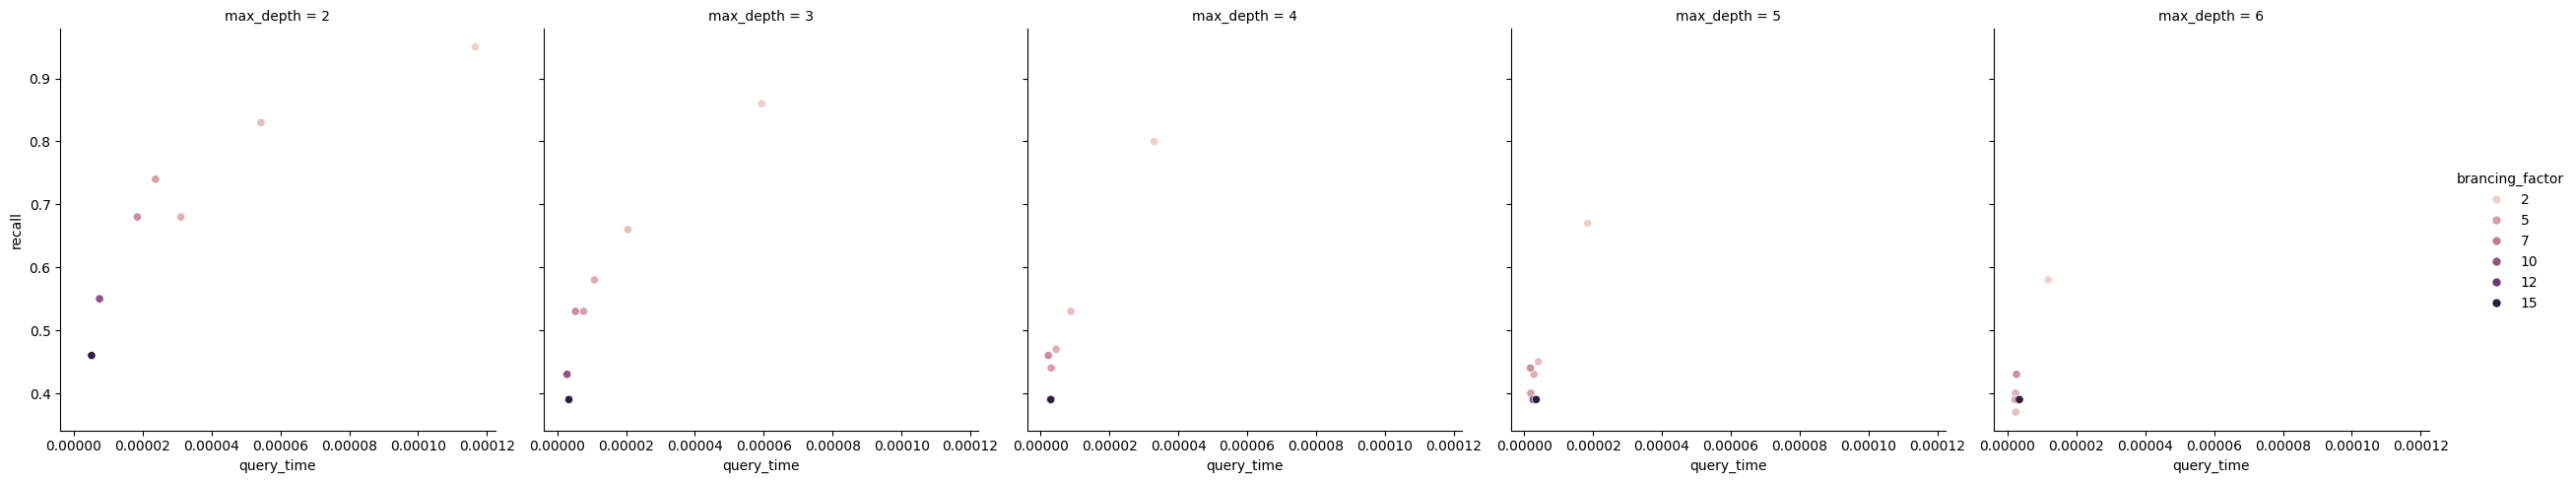

In [54]:
sns.relplot(
    data=df_2,
    x="query_time",
    y="recall",
    hue="brancing_factor",
    col="max_depth",
    kind="scatter"
)


<Axes: xlabel='brancing_factor', ylabel='max_depth'>

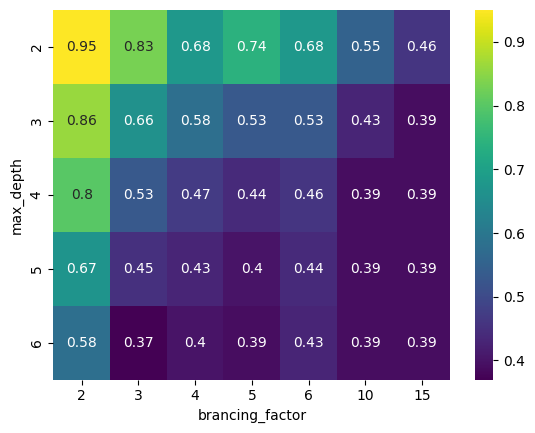

In [55]:
pivot = df_2.pivot(
    index="max_depth",
    columns="brancing_factor",
    values="recall"
)
sns.heatmap(pivot, annot=True, cmap="viridis")


<Axes: xlabel='brancing_factor', ylabel='max_depth'>

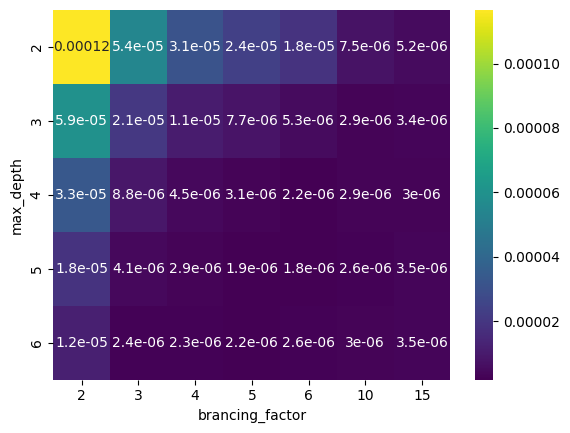

In [56]:
pivot = df_2.pivot(
    index="max_depth",
    columns="brancing_factor",
    values="query_time"
)
sns.heatmap(pivot, annot=True, cmap="viridis")